# Kauffman (1969) — Random Genetic Nets: Experiment Visualizations

This notebook visualizes the output data from all experiments defined in `main.rs`, reproducing the figures from:

> Kauffman, S. A. (1969). *Metabolic Stability and Epigenesis in Randomly Constructed Genetic Nets*. J. Theoret. Biol., 22, 437–467.

**Expected output files** (generated by `run_experiments.sh`):
```
output/
  fig_3_a.csv, fig_3_b.csv
  fig_4_n{N}_{all|excl}.csv
  fig_5.csv
  sec_5_3_activity.csv
  fig_6.csv
  fig_7_n{N}_excl.csv
  fig_8.csv
  fig_9_n{191|400}.csv
  fig_10_n{191|400}_verbose.csv
```

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os
import warnings

warnings.filterwarnings("ignore")

OUTPUT_DIR = "output"


def load(filename, output_dir=OUTPUT_DIR):
    path = os.path.join(output_dir, filename)
    if not os.path.exists(path):
        print(f"  [MISSING] {path}")
        return None
    return pd.read_csv(path)


# Consistent style across all figures
plt.rcParams.update(
    {
        "figure.dpi": 150,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
    }
)

print("Setup complete.")

Setup complete.


---
## Experiment 1 — Fig. 3: Cycle Length Histograms

**Paper description:** Histograms of state-cycle lengths in nets of 400 binary elements.
- **(a)** All 16 Boolean functions used equiprobably — distribution strongly skewed toward short cycles.
- **(b)** Tautology and contradiction excluded — still skewed, but mode/median shift upward.

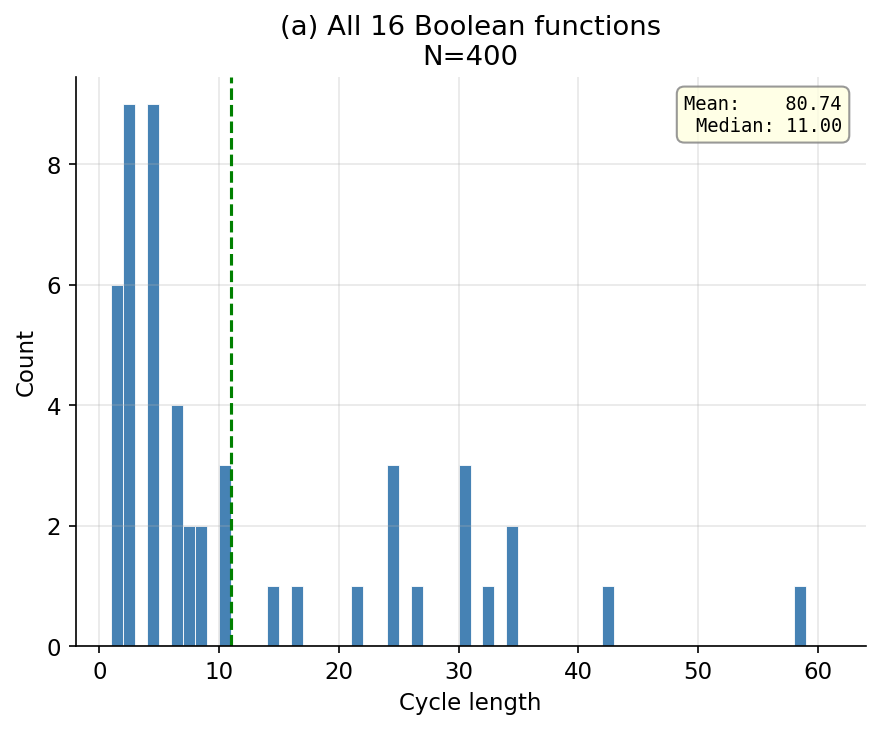

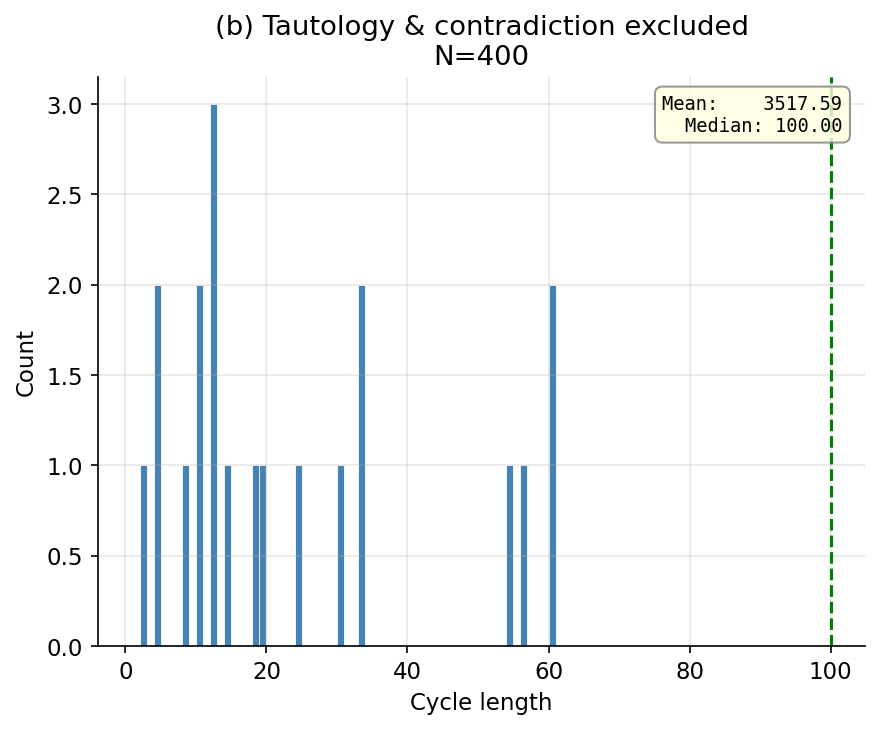

In [127]:
df_3a = load("fig_3_a.csv")
df_3b = load("fig_3_b.csv")

datasets = [
    (df_3a, "(a) All 16 Boolean functions\nN=400", "plot_fig_3a.png"),
    (df_3b, "(b) Tautology & contradiction excluded\nN=400", "plot_fig_3b.png"),
]

for df, title, filename in datasets:
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))

    if df is None:
        ax.text(
            0.5, 0.5, "Data not found", ha="center", va="center", transform=ax.transAxes
        )
        ax.set_title(title)
        plt.savefig(os.path.join(OUTPUT_DIR, filename), bbox_inches="tight")
        plt.show()
        plt.close()
        continue

    completed = df[df["max_steps_reached"] == False]["cycle_length"]
    assert len(completed) > len(df) / 2, (
        "must have completed over half of experiments for median to be valid"
    )

    cycle_lengths = df[:]["cycle_length"]
    cycle_lengths = (
        completed  # to see if this is how he got such low mean cycle lengths
    )

    max_cl = int(cycle_lengths.max()) if not cycle_lengths.empty else 60
    bins = range(1, min(max_cl + 2, 62))

    ax.hist(
        cycle_lengths[: int(cycle_lengths.count() * 0.6) + 1],
        bins=bins,
        color="steelblue",
        edgecolor="white",
        linewidth=0.4,
    )
    ax.set_xlabel("Cycle length")
    ax.set_ylabel("Count")
    ax.set_title(title)

    med = cycle_lengths.median()
    mn = cycle_lengths.mean()

    # Stats box in the upper-right corner
    stats_text = f"Mean:    {mn:.2f}\nMedian: {med:.2f}"
    ax.text(
        0.97,
        0.97,
        stats_text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="lightyellow",
            edgecolor="gray",
            alpha=0.8,
        ),
        fontfamily="monospace",
    )

    ax.axvline(
        med, color="green", linestyle="--", linewidth=1.5, label=f"Median={med:.0f}"
    )

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, filename), bbox_inches="tight")
    plt.show()
    plt.close()

---
## Experiment 1 (cont.) — Fig. 4: Log Median Cycle Length vs Log N

**Paper description:** Median cycle length plotted against net size N on log-log axes. Two curves are shown — all 16 Boolean functions (asymptotic slope ~= 0.3) and with tautology/contradiction excluded (asymptotic slope ~= 0.6).

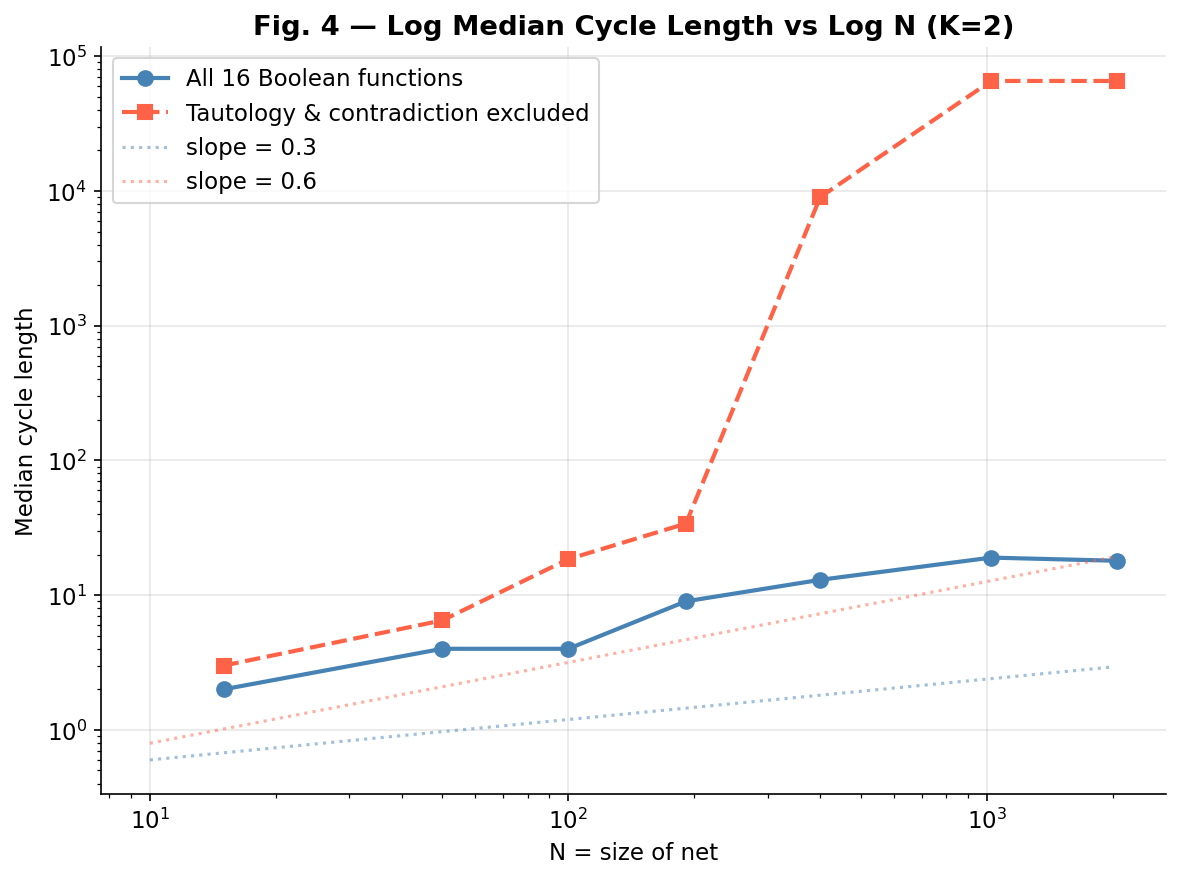

In [73]:
net_sizes = [15, 50, 100, 191, 400, 1024, 2048]

records_all = []
records_excl = []

for n in net_sizes:
    for records, suffix in [(records_all, "all"), (records_excl, "excl")]:
        df = load(f"fig_4_n{n}_{suffix}.csv")
        if df is not None:
            # completed = df[df["max_steps_reached"] == False]["cycle_length"]
            # assert len(completed) > len(df) / 2, (
            #     f"fig_4_n{n}_{suffix}.csv must have completed over half of experiments for median to be valid"
            # )

            # doing this just to illustrate a point
            completed = df[:]["cycle_length"]
            if not completed.empty:
                records.append({"N": n, "median_cycle": completed.median()})

df_all = pd.DataFrame(records_all)
df_excl = pd.DataFrame(records_excl)

fig, ax = plt.subplots(figsize=(6, 5))

if not df_all.empty:
    ax.loglog(
        df_all["N"],
        df_all["median_cycle"],
        "o-",
        color="steelblue",
        label="All 16 Boolean functions",
        linewidth=2,
        markersize=7,
    )

if not df_excl.empty:
    ax.loglog(
        df_excl["N"],
        df_excl["median_cycle"],
        "s--",
        color="tomato",
        label="Tautology & contradiction excluded",
        linewidth=2,
        markersize=7,
    )

# Reference slope lines
n_ref = np.array([10, 2000])
ax.loglog(
    n_ref, 0.3 * n_ref**0.3, ":", color="steelblue", alpha=0.5, label="slope = 0.3"
)
ax.loglog(n_ref, 0.2 * n_ref**0.6, ":", color="tomato", alpha=0.5, label="slope = 0.6")

ax.set_xlabel("N = size of net")
ax.set_ylabel("Median cycle length")
ax.set_title("Fig. 4 — Log Median Cycle Length vs Log N (K=2)", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_fig_4.png"), bbox_inches="tight")
plt.show()

---
## Experiment 2 — Fig. 5: Scattergram of Run-in Length vs Cycle Length

**Paper description:** Run-in (transient) length appears uncorrelated with cycle length. Log/log axes used to accommodate the data. N=400, tautology and contradiction excluded.

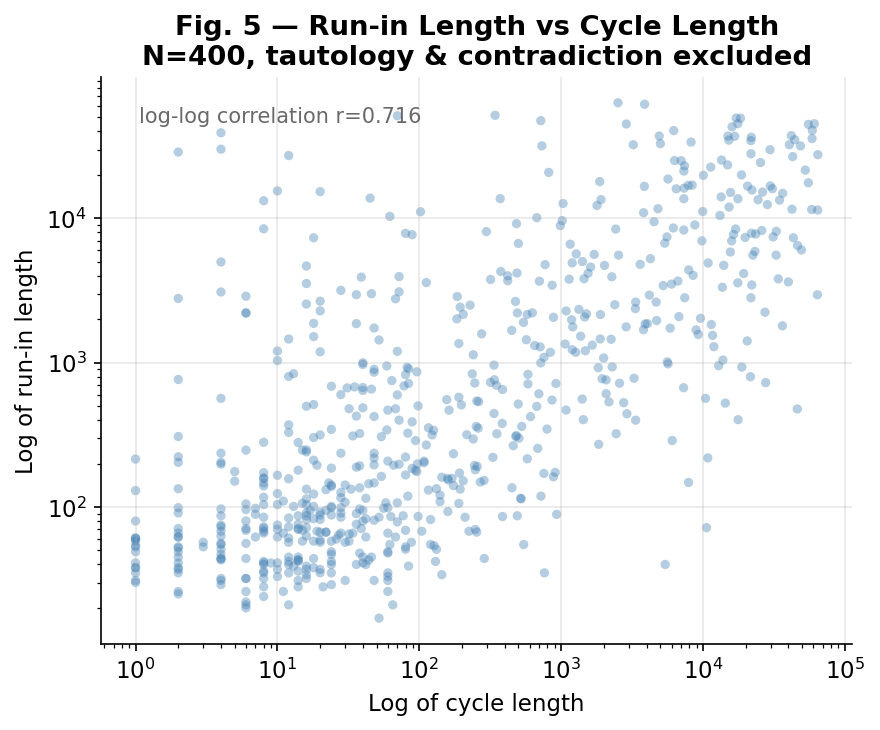

In [83]:
df_5 = load("fig_5.csv")

fig, ax = plt.subplots(figsize=(6, 5))

if df_5 is not None:
    completed = df_5[df_5["max_steps_reached"] == False]
    # Clamp zeros to 1 for log scale
    cl = completed["cycle_length"].clip(lower=1)
    tr = completed["transient"].clip(lower=1)
    ax.scatter(cl, tr, alpha=0.4, s=20, color="steelblue", edgecolors="none")
    corr = np.corrcoef(np.log(cl), np.log(tr))[0, 1]
    ax.text(
        0.05,
        0.92,
        f"log-log correlation r={corr:.3f}",
        transform=ax.transAxes,
        fontsize=10,
        color="dimgray",
    )
else:
    ax.text(
        0.5, 0.5, "Data not found", ha="center", va="center", transform=ax.transAxes
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Log of cycle length")
ax.set_ylabel("Log of run-in length")
ax.set_title(
    "Fig. 5 — Run-in Length vs Cycle Length\nN=400, tautology & contradiction excluded",
    fontweight="bold",
)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_fig_5.png"), bbox_inches="tight")
plt.show()

---
## Experiment 3 — Section 5.3: Activity Decay Toward Cycle

**Paper description:** Activity (fraction of genes changing value per step) decreases rapidly from ~0.4N at the first transition, following a near-exponential decay with half-life of 3–4 steps. N=100, all 16 Boolean functions.

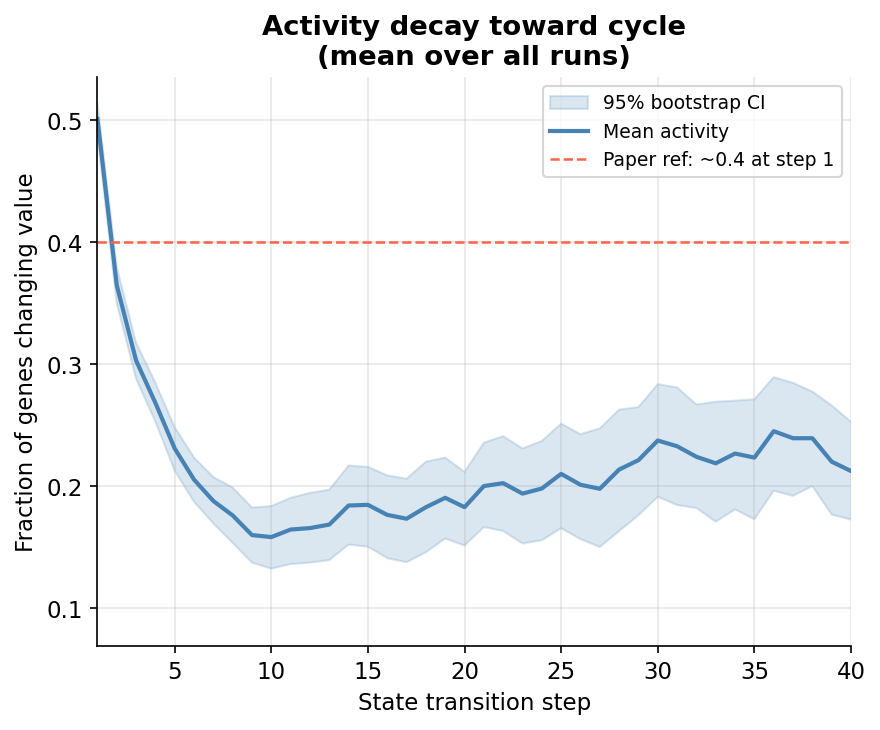

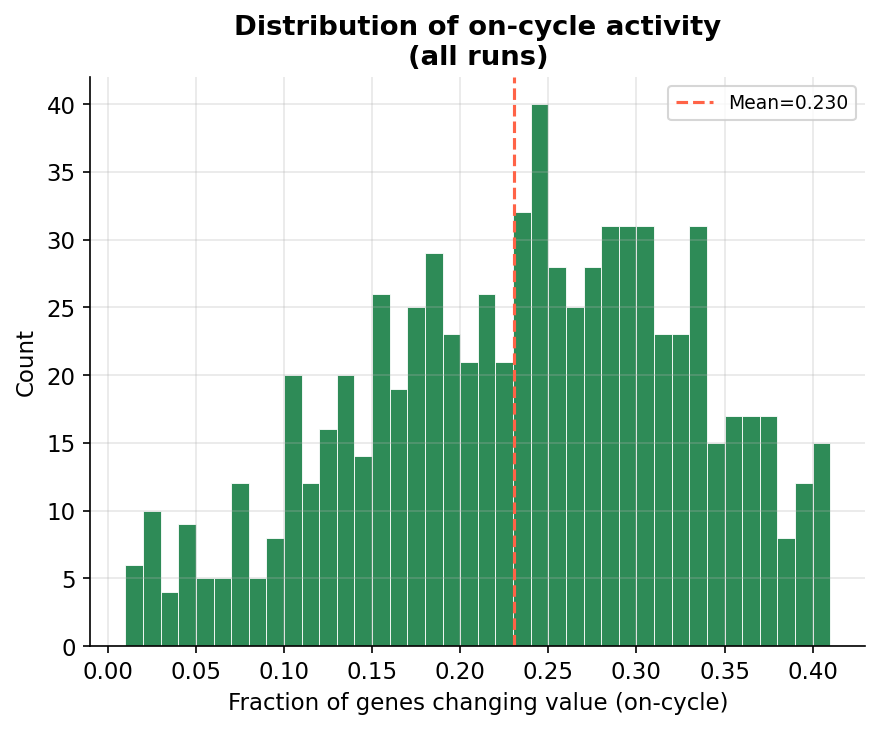

In [85]:
path = os.path.join(OUTPUT_DIR, "sec_5_3_activity.csv")

if not os.path.exists(path):
    print(f"bad path: {path}")
else:
    # The output alternates: header line (transient, cycle_length), then a
    # comma-separated row of pairwise Hamming distances for that run.
    all_distances = []
    meta = []
    with open(path) as f:
        lines = [l.strip() for l in f if l.strip()]

    i = 0
    while i + 1 < len(lines):
        try:
            parts = lines[i].split(",")
            transient = int(parts[0].strip())
            cycle_len = int(parts[1].strip())
            dists = [float(x) for x in lines[i + 1].split(",") if x.strip()]
            meta.append({"transient": transient, "cycle_length": cycle_len})
            all_distances.append((transient, cycle_len, dists))
            i += 2
        except (ValueError, IndexError):
            i += 1

    # --- Bootstrap CI for mean activity ---
    n_boot = 1000
    rng = np.random.default_rng(42)
    boot_means = np.array(
        [
            np.nanmean(arr[rng.integers(0, len(arr), size=len(arr))], axis=0)
            for _ in range(n_boot)
        ]
    )
    ci_low = np.nanpercentile(boot_means, 2.5, axis=0)
    ci_high = np.nanpercentile(boot_means, 97.5, axis=0)

    # --- Plot 1: Mean activity decay across runs (approach to cycle) ---
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))

    max_len = max(len(d) for _, _, d in all_distances) if all_distances else 0
    padded = []
    for transient, _, d in all_distances:
        padded.append(d + [np.nan] * (max_len - len(d)))
    arr = np.array(padded, dtype=float)
    mean_activity = np.nanmean(arr, axis=0)
    steps = np.arange(1, len(mean_activity) + 1)

    ax.fill_between(
        steps,
        ci_low,
        ci_high,
        color="steelblue",
        alpha=0.2,
        label="95% bootstrap CI",
    )
    ax.plot(steps, mean_activity, color="steelblue", linewidth=2, label="Mean activity")
    ax.axhline(
        0.4,
        linestyle="--",
        color="tomato",
        linewidth=1.2,
        label="Paper ref: ~0.4 at step 1",
    )
    ax.set_xlabel("State transition step")
    ax.set_ylabel("Fraction of genes changing value")
    ax.set_title("Activity decay toward cycle\n(mean over all runs)", fontweight="bold")
    ax.set_xlim(1, min(40, max_len))
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "plot_sec_5_3_decay.png"), bbox_inches="tight")
    plt.show()

    # --- Plot 2: Distribution of on-cycle activity (genes changing per cycle step) ---
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    on_cycle_activities = []
    for transient, cycle_len, d in all_distances:
        if len(d) > transient and cycle_len > 0:
            on_cycle_activities.extend(d[transient:])

    if on_cycle_activities:
        ax.hist(
            on_cycle_activities,
            bins=40,
            color="seagreen",
            edgecolor="white",
            linewidth=0.4,
        )
        ax.set_xlabel("Fraction of genes changing value (on-cycle)")
        ax.set_ylabel("Count")
        ax.set_title("Distribution of on-cycle activity\n(all runs)", fontweight="bold")
        mn = np.mean(on_cycle_activities)
        ax.axvline(
            mn, color="tomato", linestyle="--", linewidth=1.5, label=f"Mean={mn:.3f}"
        )
        ax.legend(fontsize=9)
    else:
        ax.text(
            0.5,
            0.5,
            "No on-cycle data",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )

    # fig.suptitle(
    #     "Section 5.3 — Activity (N=100, all 16 Boolean functions)",
    #     fontsize=13,
    #     fontweight="bold",
    # )
    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, "plot_sec_5_3_on_cycle.png"), bbox_inches="tight"
    )
    plt.show()

---
## Experiment 4 — Fig. 6: Histogram of Number of Cycles per Net

**Paper description:** The number of independent behavior cycles (modes) per net is surprisingly small and skewed toward few cycles. N=400, tautology and contradiction excluded. Median ~= 10 cycles per net.

Median cycles per net: 12.0


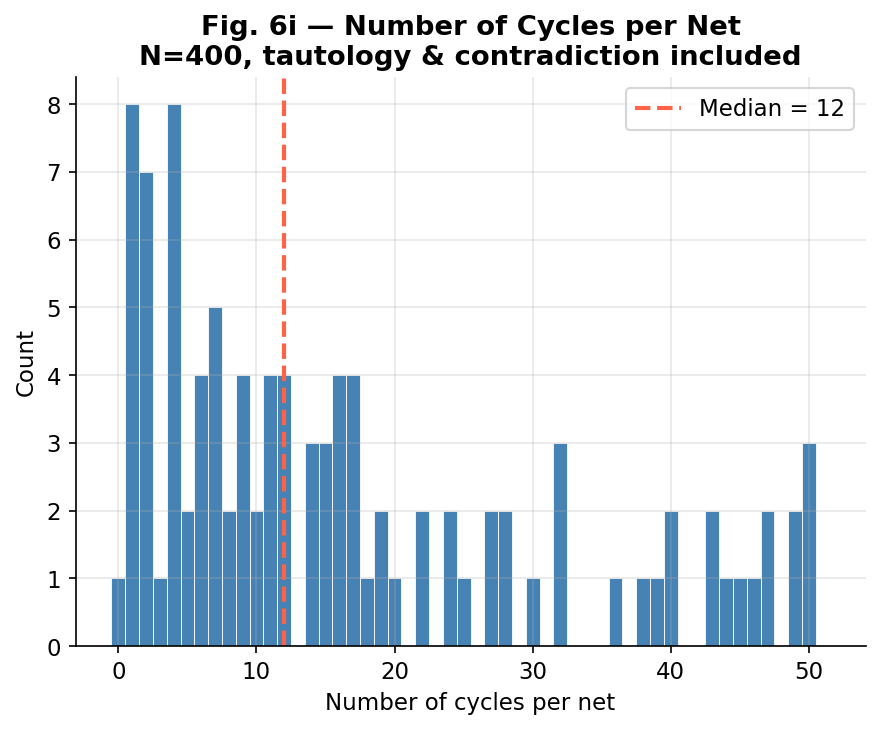

Median cycles per net: 3.0


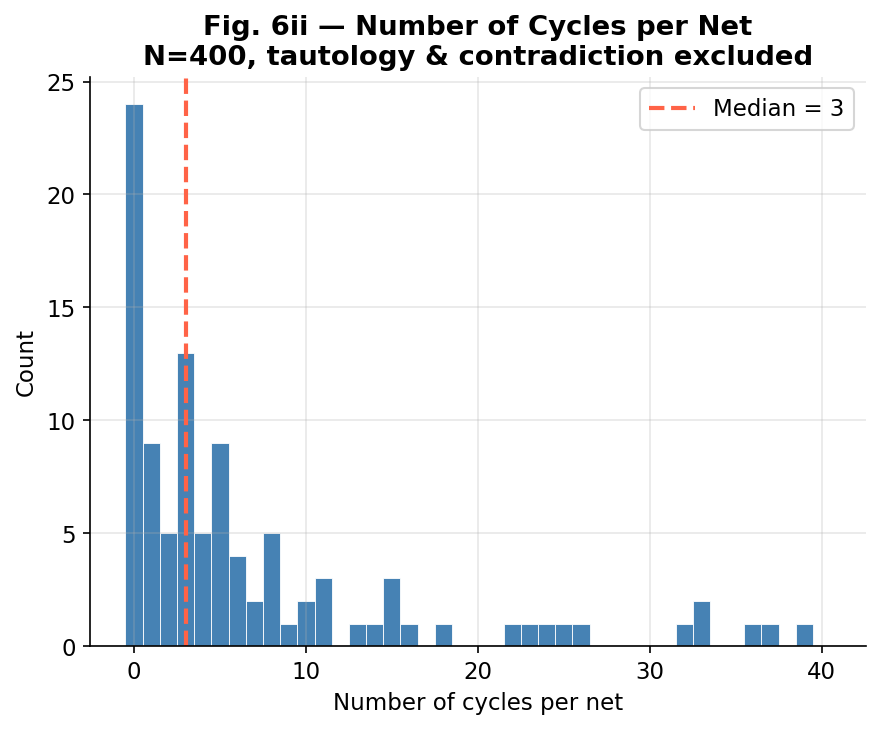

In [88]:
for suffix, full, eyes in [("all", "included", "i"), ("excl", "excluded", "ii")]:
    df_6 = load(f"fig_6_{suffix}.csv")

    fig, ax = plt.subplots(figsize=(6, 5))

    if df_6 is not None:
        cycles = df_6["unique_cycles"]
        max_c = int(cycles.max())
        bins = range(0, max_c + 3)
        ax.hist(
            cycles,
            bins=bins,
            color="steelblue",
            edgecolor="white",
            linewidth=0.4,
            align="left",
        )
        med = cycles.median()
        ax.axvline(
            med,
            color="tomato",
            linestyle="--",
            linewidth=2,
            label=f"Median = {med:.0f}",
        )
        ax.set_xlabel("Number of cycles per net")
        ax.set_ylabel("Count")
        ax.legend()
        print(f"Median cycles per net: {med}")
    else:
        ax.text(
            0.5, 0.5, "Data not found", ha="center", va="center", transform=ax.transAxes
        )

    ax.set_title(
        f"Fig. 6{eyes} — Number of Cycles per Net\nN=400, tautology & contradiction {full}",
        fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "plot_fig_6.png"), bbox_inches="tight")
    plt.show()

---
## Experiment 4 (cont.) — Fig. 7: Log Median Cycles per Net vs Log N

**Paper description:** Log-log plot showing the median number of cycles per net scales as approximately sqrt(N) (slope ~= 0.5). Tautology and contradiction excluded.

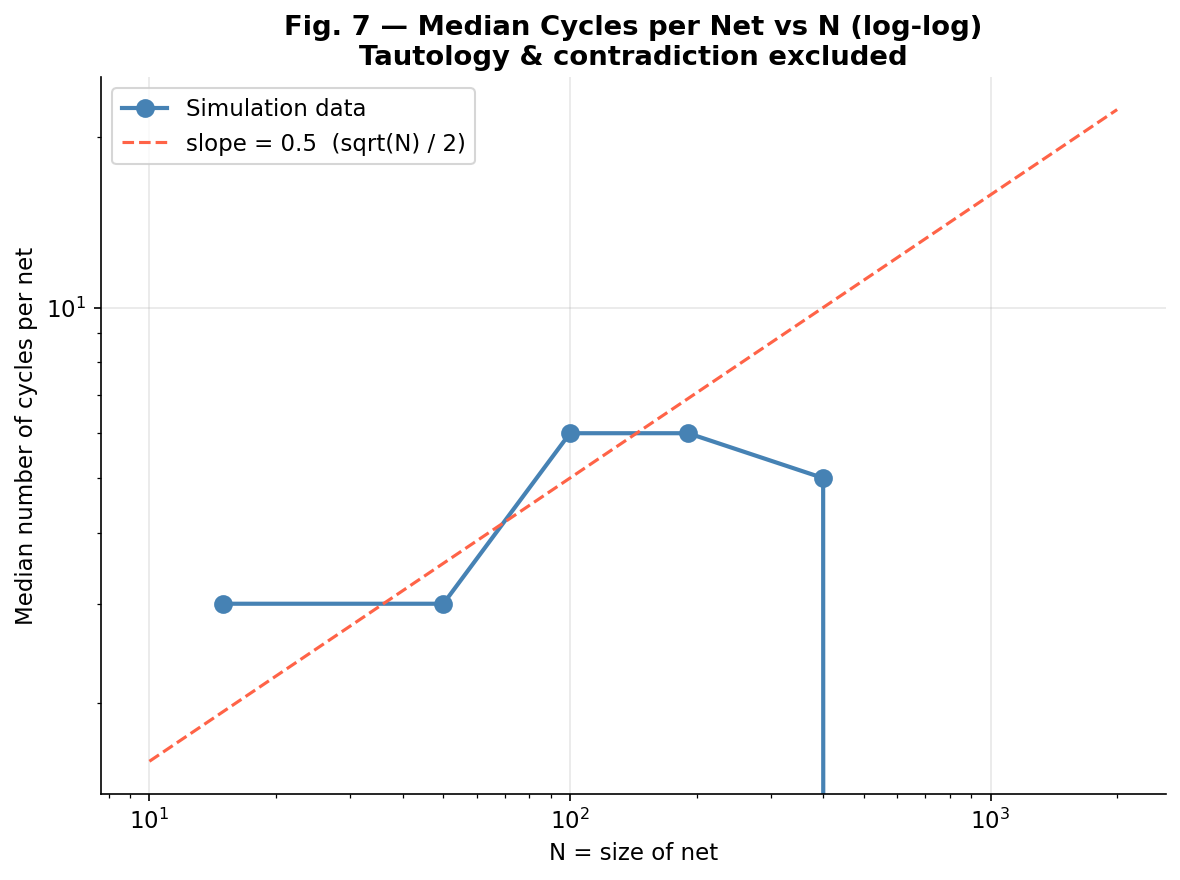

In [78]:
net_sizes_7 = [15, 50, 100, 191, 400, 1024]
records_7 = []

for n in net_sizes_7:
    df = load(f"fig_7_n{n}_excl.csv")
    if df is not None:
        med = df["unique_cycles"].median()
        records_7.append({"N": n, "median_cycles": med})

df_7 = pd.DataFrame(records_7)

fig, ax = plt.subplots(figsize=(6, 5))

if not df_7.empty:
    ax.loglog(
        df_7["N"],
        df_7["median_cycles"],
        "o-",
        color="steelblue",
        linewidth=2,
        markersize=8,
        label="Simulation data",
    )

# Reference line: slope 0.5 (sqrt N)
n_ref = np.array([10, 2000])
ax.loglog(
    n_ref,
    0.5 * n_ref**0.5,
    "--",
    color="tomato",
    linewidth=1.5,
    label="slope = 0.5  (sqrt(N) / 2)",
)

ax.set_xlabel("N = size of net")
ax.set_ylabel("Median number of cycles per net")
ax.set_title(
    "Fig. 7 — Median Cycles per Net vs N (log-log)\nTautology & contradiction excluded",
    fontweight="bold",
)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_fig_7.png"), bbox_inches="tight")
plt.show()

---
## Experiment 5 — Fig. 8: Minimum Distance Between Cycles vs Cycle Length

**Paper description:** Scattergram of minimum Hamming distance between distinct cycles vs cycle length. Distance appears uncorrelated with cycle length. Median minimum distance ~= 0.05N. N=100, all 16 Boolean functions. Distance is normalised by N.

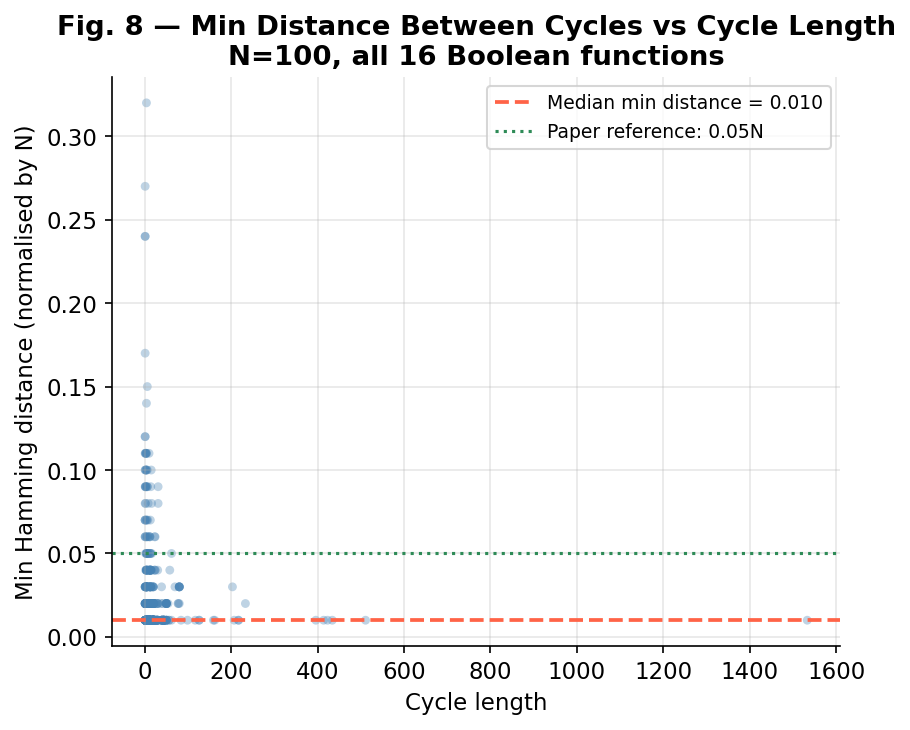

In [104]:
df_8 = load("fig_8.csv")

fig, ax = plt.subplots(figsize=(6, 5))

if df_8 is not None:
    ax.scatter(
        df_8["cycle_length"],
        df_8["min_distance"],
        alpha=0.35,
        s=18,
        color="steelblue",
        edgecolors="none",
    )
    med = df_8["min_distance"].median()
    ax.axhline(
        med,
        color="tomato",
        linestyle="--",
        linewidth=1.8,
        label=f"Median min distance = {med:.3f}",
    )
    ax.axhline(
        0.05,
        color="seagreen",
        linestyle=":",
        linewidth=1.5,
        label="Paper reference: 0.05N",
    )
    ax.set_xlabel("Cycle length")
    ax.set_ylabel("Min Hamming distance (normalised by N)")
    ax.legend(fontsize=9)
else:
    ax.text(
        0.5, 0.5, "Data not found", ha="center", va="center", transform=ax.transAxes
    )

ax.set_title(
    "Fig. 8 — Min Distance Between Cycles vs Cycle Length\nN=100, all 16 Boolean functions",
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_fig_8.png"), bbox_inches="tight")
plt.show()

---
## Experiment 6 — Fig. 9: Noise Perturbations and Cycle Reachability

**Paper description:**
- **(a)** Total number of distinct cycles reachable from each cycle under all possible single-bit perturbations, vs number of cycles in the net.
- **(b)** Same, but only cycles reachable with probability > 0.01.

Systems are highly stable — they return to their own cycle with probability 0.85–0.95. Transitions to other cycles are restricted to only 1–6 others.

  [MISSING] output/fig_9_n400.csv


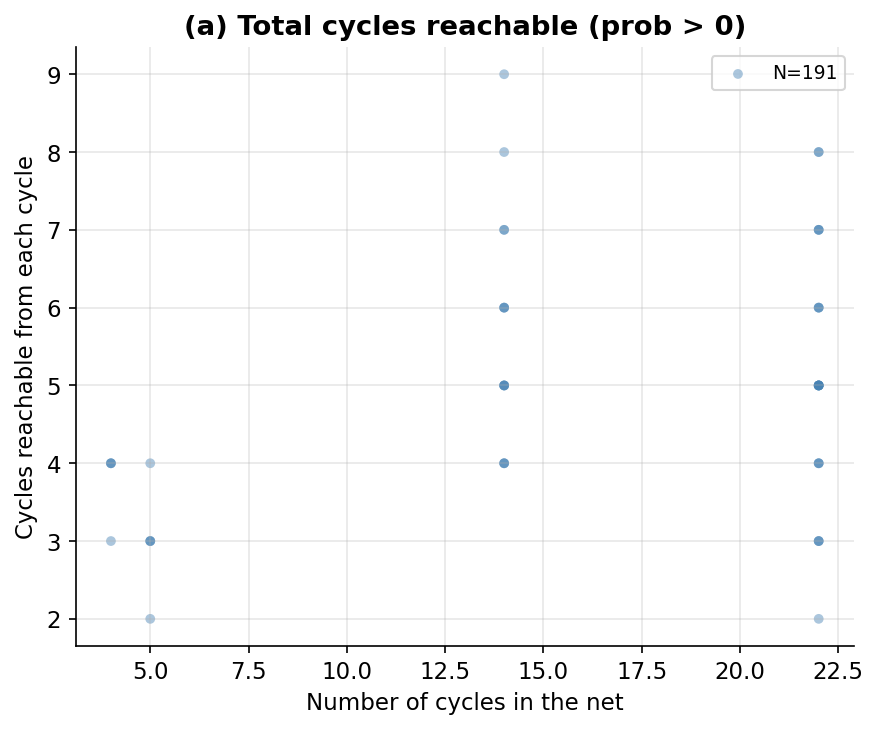

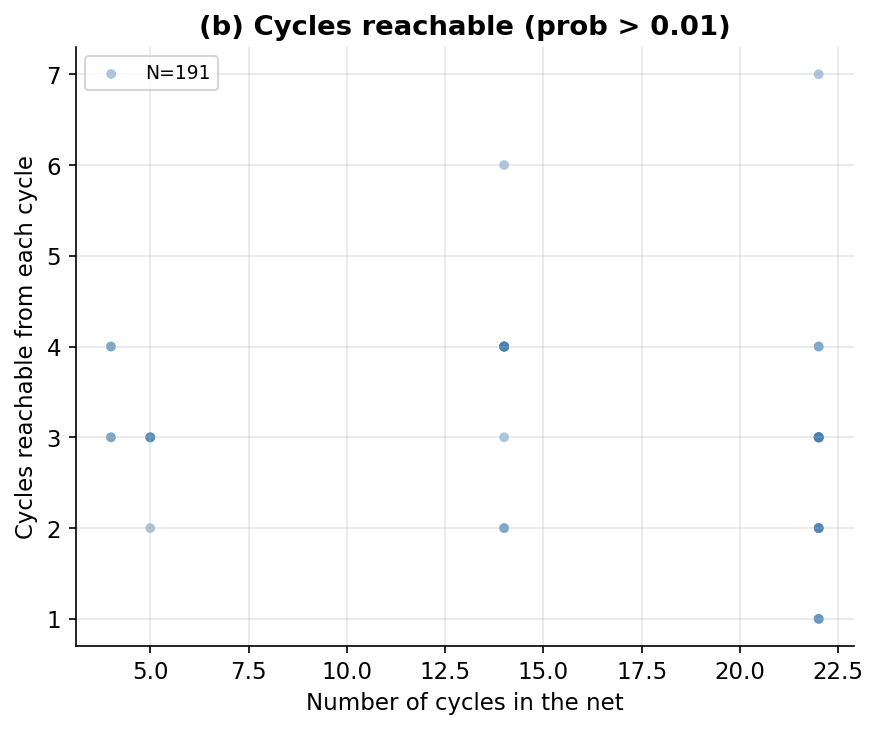

In [111]:
df_9_191 = load("fig_9_n191.csv")
df_9_400 = load("fig_9_n400.csv")

# Combine both net sizes as in the paper
frames = [df for df in [df_9_191, df_9_400] if df is not None]
df_9 = pd.concat(frames, ignore_index=True) if frames else None


panel_configs = [
    ("total_reachable", "(a) Total cycles reachable (prob > 0)"),
    ("reachable_above_0.01", "(b) Cycles reachable (prob > 0.01)"),
]

for col, title in panel_configs:
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))

    if df_9 is None or col not in df_9.columns:
        ax.text(
            0.5, 0.5, "Data not found", ha="center", va="center", transform=ax.transAxes
        )
        ax.set_title(title)
        continue

    for n_val, color, marker in [(191, "steelblue", "o"), (400, "tomato", "s")]:
        subset = df_9[
            df_9["net"].isin(
                df_9_191["net"].unique()
                if n_val == 191 and df_9_191 is not None
                else df_9_400["net"].unique()
                if df_9_400 is not None
                else []
            )
        ]
        if subset.empty:
            continue
        ax.scatter(
            subset["num_cycles"],
            subset[col],
            alpha=0.45,
            s=22,
            color=color,
            marker=marker,
            edgecolors="none",
            label=f"N={n_val}",
        )

    ax.set_xlabel("Number of cycles in the net")
    ax.set_ylabel("Cycles reachable from each cycle")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9)

    # fig.suptitle(
    #     "Fig. 9 — Noise Perturbations: Cycle Reachability\n(N=191 & N=400, tautology & contradiction excluded)",
    #     fontsize=12,
    #     fontweight="bold",
    # )
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "plot_fig_9.png"), bbox_inches="tight")
    plt.show()

---
## Experiment 6 (cont.) — Fig. 9 Summary: Return-to-Self Stability

**Paper description:** Nets generally return to the cycle perturbed with probability 0.85–0.95. This panel shows the distribution of self-return probability across all cycles and both net sizes.

In [112]:
# for df, label in [(df_9_191, "N=191"), (df_9_400, "N=400")]:
#     fig, ax = plt.subplots(1, 1, figsize=(6, 5))

#     if df is None:
#         ax.text(
#             0.5, 0.5, "Data not found", ha="center", va="center", transform=ax.transAxes
#         )
#         ax.set_title(label)
#         continue

#     ax.scatter(
#         df["num_cycles"],
#         df["total_reachable"],
#         alpha=0.5,
#         s=25,
#         color="steelblue",
#         label="Total reachable",
#         edgecolors="none",
#     )
#     ax.scatter(
#         df["num_cycles"],
#         df["reachable_above_0.01"],
#         alpha=0.5,
#         s=25,
#         color="tomato",
#         marker="s",
#         label="Reachable (p>0.01)",
#         edgecolors="none",
#     )

#     ax.set_xlabel("Number of cycles in net")
#     ax.set_ylabel("Cycles reachable from each source cycle")
#     ax.set_title(f"Reachability — {label}", fontweight="bold")
#     ax.legend(fontsize=9)

#     # fig.suptitle(
#     #     "Fig. 9 — Reachability per source cycle by net size", fontsize=12, fontweight="bold"
#     # )
#     plt.tight_layout()
#     plt.savefig(
#         os.path.join(OUTPUT_DIR, f"plot_fig_9_by_n_{label.split('=')[-1]}.png"),
#         bbox_inches="tight",
#     )
#     plt.show()

---
## Experiment 6 (cont.) — Fig. 10: Markov Transition Matrix

**Paper description:** The verbose output includes the full transition probability matrix between cycles for each net. This cell parses a single representative net from the stderr verbose output and displays it as a heatmap.

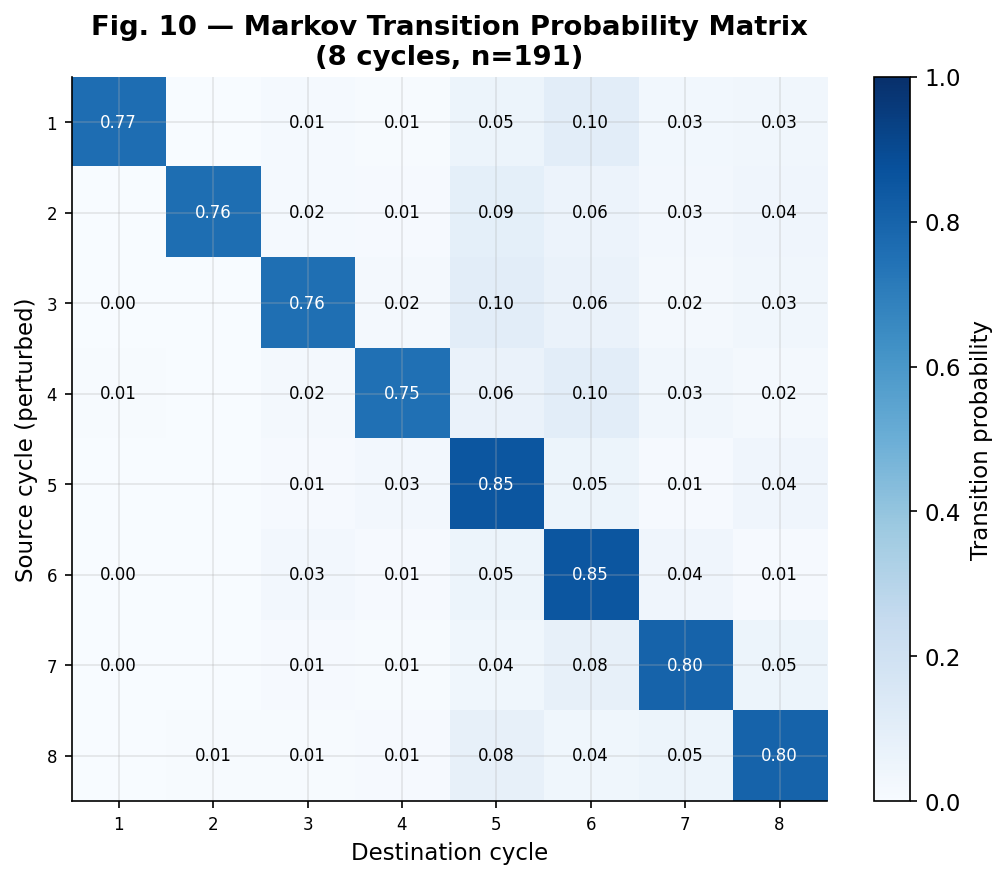


Self-return probability stats (diagonal):
  Min:    0.753
  Max:    0.855
  Mean:   0.794
  Median: 0.784
  Paper reports: 0.85–0.95


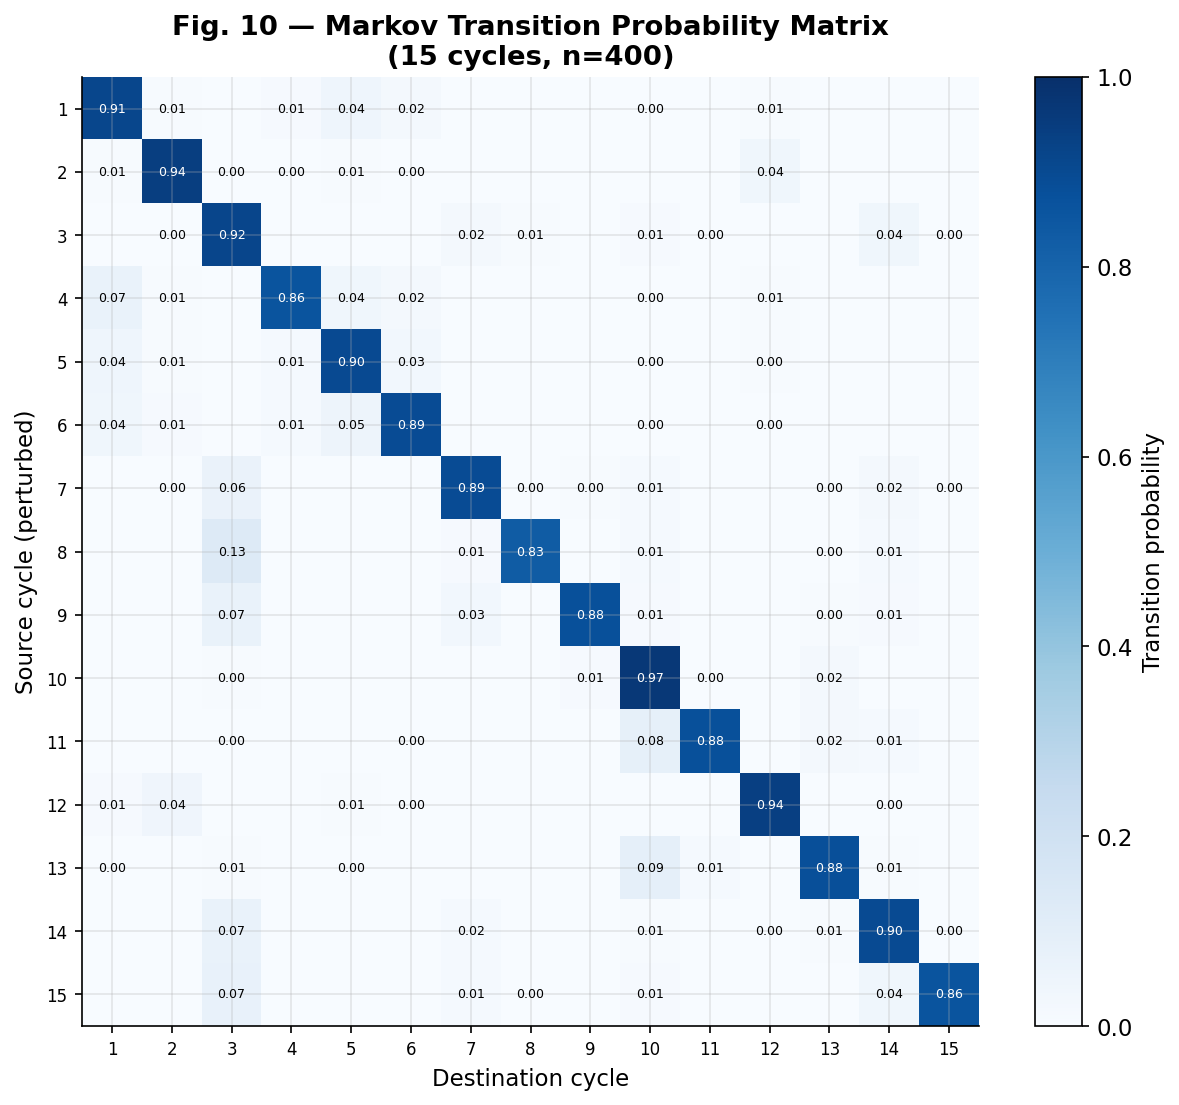


Self-return probability stats (diagonal):
  Min:    0.831
  Max:    0.966
  Mean:   0.896
  Median: 0.891
  Paper reports: 0.85–0.95


In [118]:
for n in [191, 400]:
    csv_path = os.path.join(OUTPUT_DIR, f"fig_10_n{n}.csv")

    mat = None
    if not os.path.exists(csv_path):
        print(f"File not found: {csv_path}")
    else:
        counts = np.loadtxt(csv_path, delimiter=",")
        row_sums = counts.sum(axis=1, keepdims=True)
        mat = counts / row_sums

    if mat is not None:
        n_cyc = mat.shape[0]
        fig, ax = plt.subplots(figsize=(max(7, n_cyc * 0.55), max(6, n_cyc * 0.5)))
        im = ax.imshow(mat, cmap="Blues", vmin=0, vmax=1, aspect="auto")
        plt.colorbar(im, ax=ax, label="Transition probability")
        ax.set_xticks(range(n_cyc))
        ax.set_yticks(range(n_cyc))
        ax.set_xticklabels([str(i + 1) for i in range(n_cyc)], fontsize=8)
        ax.set_yticklabels([str(i + 1) for i in range(n_cyc)], fontsize=8)
        ax.set_xlabel("Destination cycle")
        ax.set_ylabel("Source cycle (perturbed)")
        for i in range(n_cyc):
            for j in range(n_cyc):
                val = mat[i, j]
                if val > 0.001:
                    color = "white" if val > 0.6 else "black"
                    ax.text(
                        j,
                        i,
                        f"{val:.2f}",
                        ha="center",
                        va="center",
                        fontsize=max(5, 9 - n_cyc // 5),
                        color=color,
                    )
        ax.set_title(
            f"Fig. 10 — Markov Transition Probability Matrix\n({n_cyc} cycles, {n=})",
            fontweight="bold",
        )
        plt.tight_layout()
        plt.savefig(
            os.path.join(OUTPUT_DIR, "plot_fig_10_heatmap.png"), bbox_inches="tight"
        )
        plt.show()

        diag = np.diag(mat)
        print(f"\nSelf-return probability stats (diagonal):")
        print(f"  Min:    {diag.min():.3f}")
        print(f"  Max:    {diag.max():.3f}")
        print(f"  Mean:   {diag.mean():.3f}")
        print(f"  Median: {np.median(diag):.3f}")
        print(f"  Paper reports: 0.85–0.95")

---
## Summary Table

A consolidated summary of key statistics from all experiments.

In [128]:
rows = []

# Fig 3a
if df_3a is not None:
    c = df_3a[df_3a["max_steps_reached"] == False]["cycle_length"]
    rows.append(
        {
            "Figure": "Fig 3(a)",
            "Condition": "N=400, all 16 fns",
            "Median": c.median(),
            "Mean": c.mean(),
            "Mode": c.mode()[0],
        }
    )

# Fig 3b
if df_3b is not None:
    c = df_3b[df_3b["max_steps_reached"] == False]["cycle_length"]
    rows.append(
        {
            "Figure": "Fig 3(b)",
            "Condition": "N=400, excl taut/cont",
            "Median": c.median(),
            "Mean": c.mean(),
            "Mode": c.mode()[0],
        }
    )

# Fig 6
if df_6 is not None:
    c = df_6["unique_cycles"]
    rows.append(
        {
            "Figure": "Fig 6",
            "Condition": "Cycles/net, N=400 excl",
            "Median": c.median(),
            "Mean": round(c.mean(), 2),
            "Mode": c.mode()[0],
        }
    )

# Fig 8
if df_8 is not None:
    c = df_8["min_distance"]
    rows.append(
        {
            "Figure": "Fig 8",
            "Condition": "Min dist/N, N=100 all fns",
            "Median": round(c.median(), 4),
            "Mean": round(c.mean(), 4),
            "Mode": round(c.mode()[0], 4),
        }
    )

if rows:
    summary = pd.DataFrame(rows).set_index("Figure")
    display(summary)
else:
    print("No data loaded — run the shell script first.")

,Condition,Median,Mean,Mode
Figure,,,,
Fig 3(a),"N=400, all 16 fns",11.00,80.740000,1.00
Fig 3(b),"N=400, excl taut/cont",100.00,3517.585714,2.00
Fig 6,"Cycles/net, N=400 excl",3.00,6.990000,0.00
Fig 8,"Min dist/N, N=100 all fns",0.01,0.022400,0.01


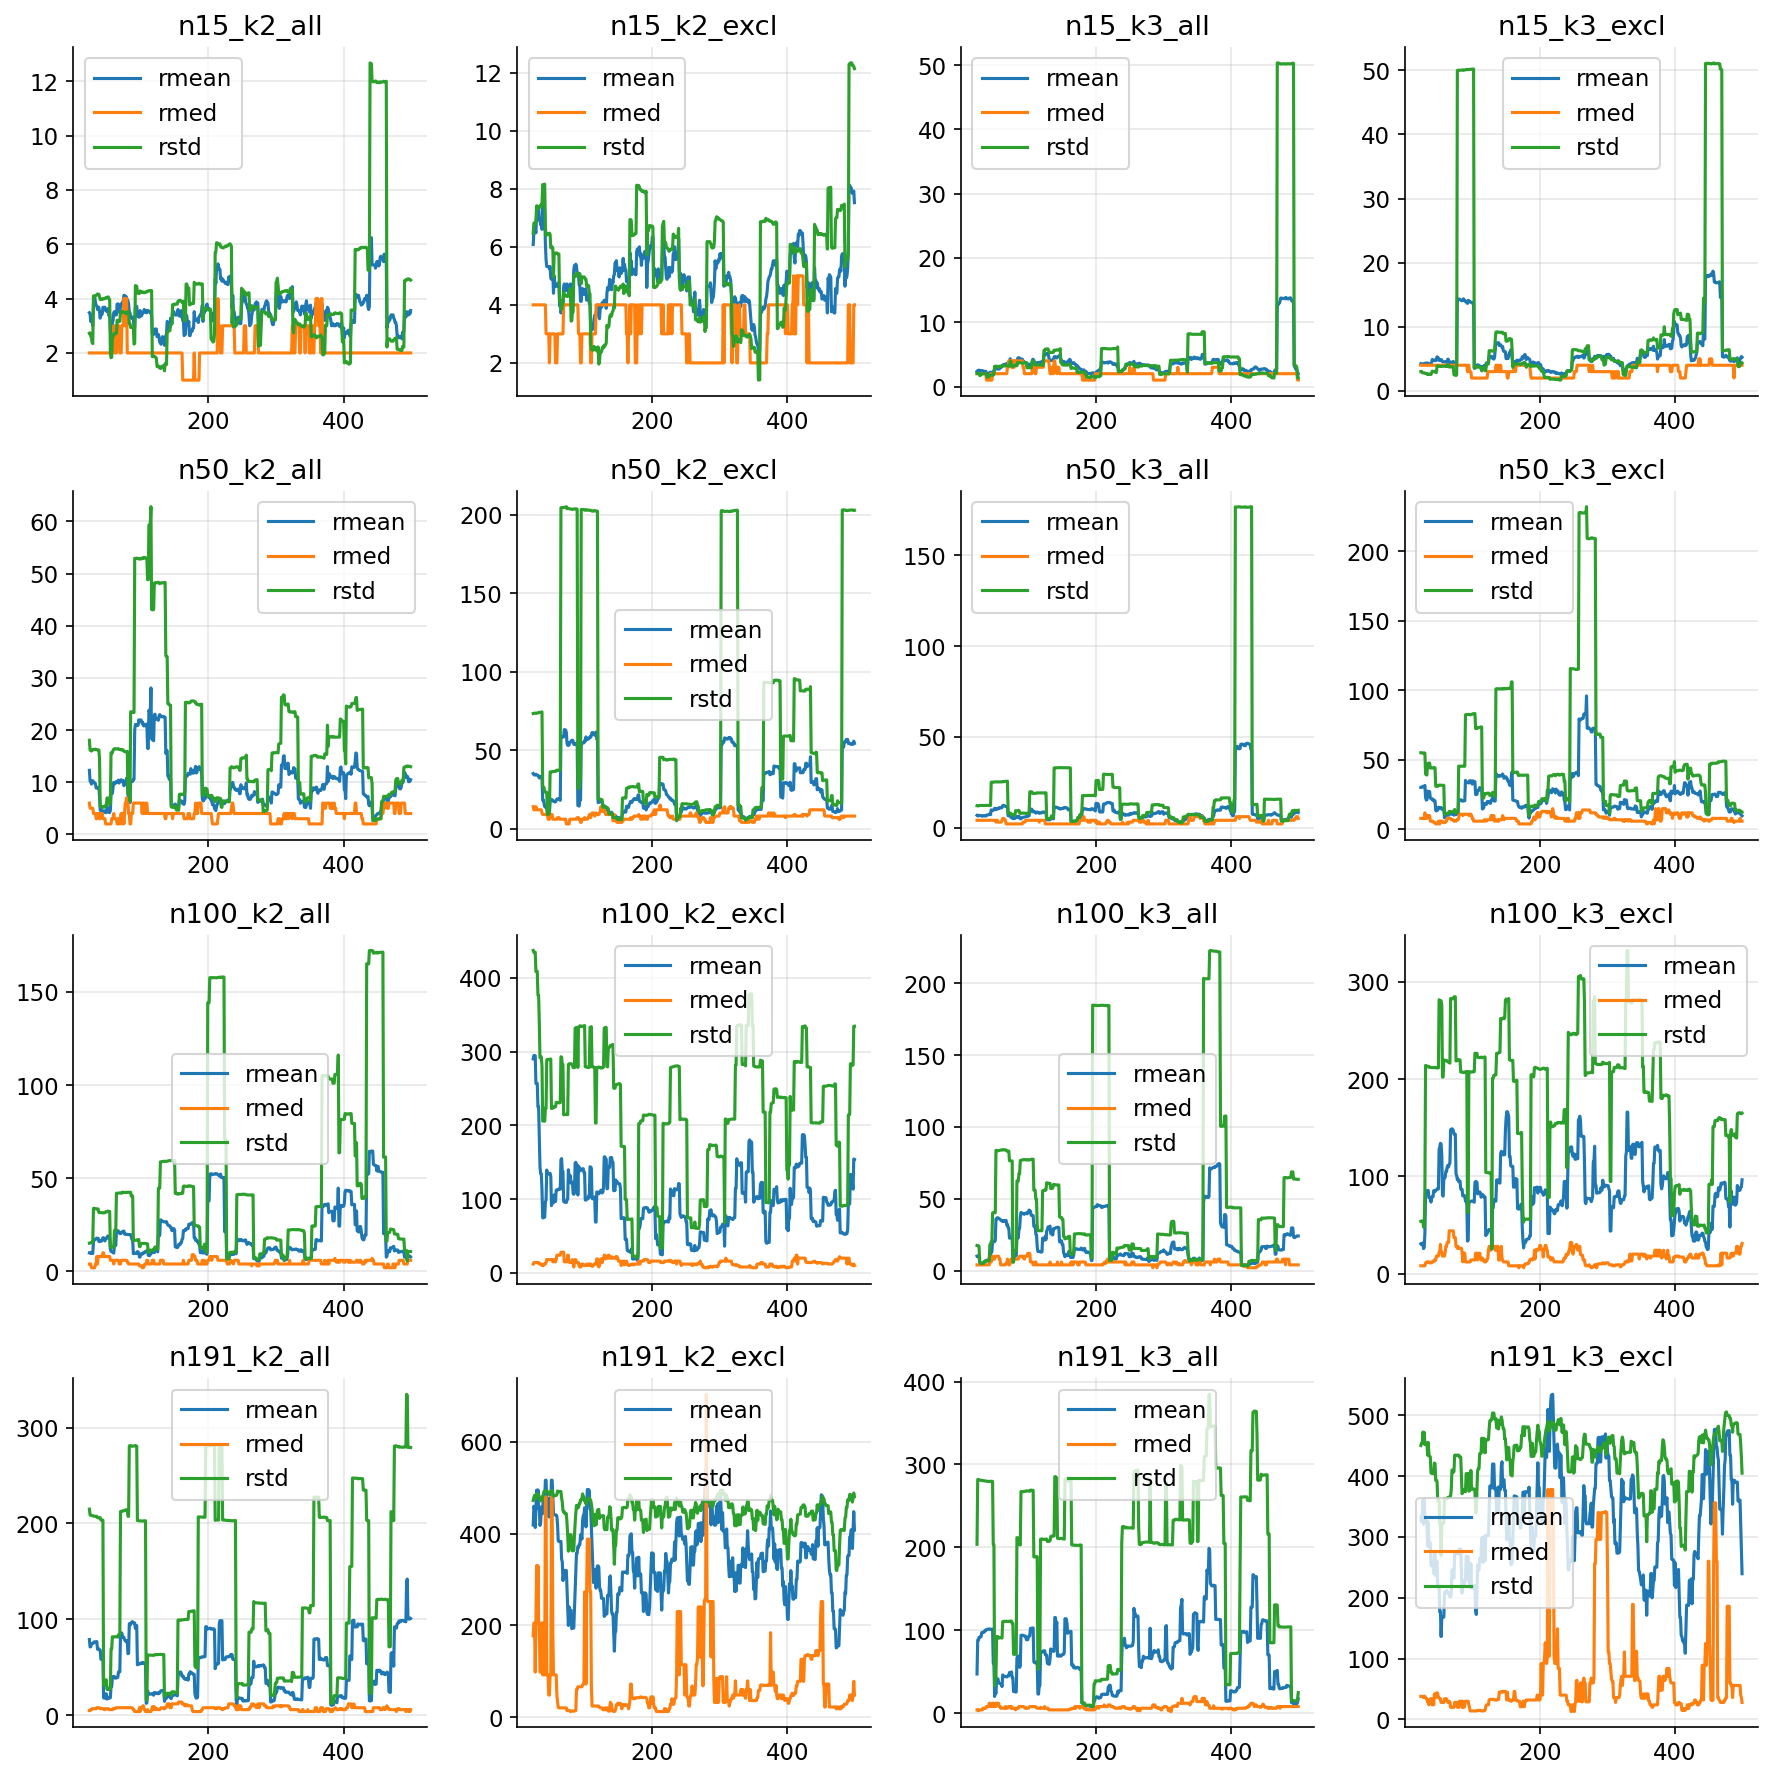

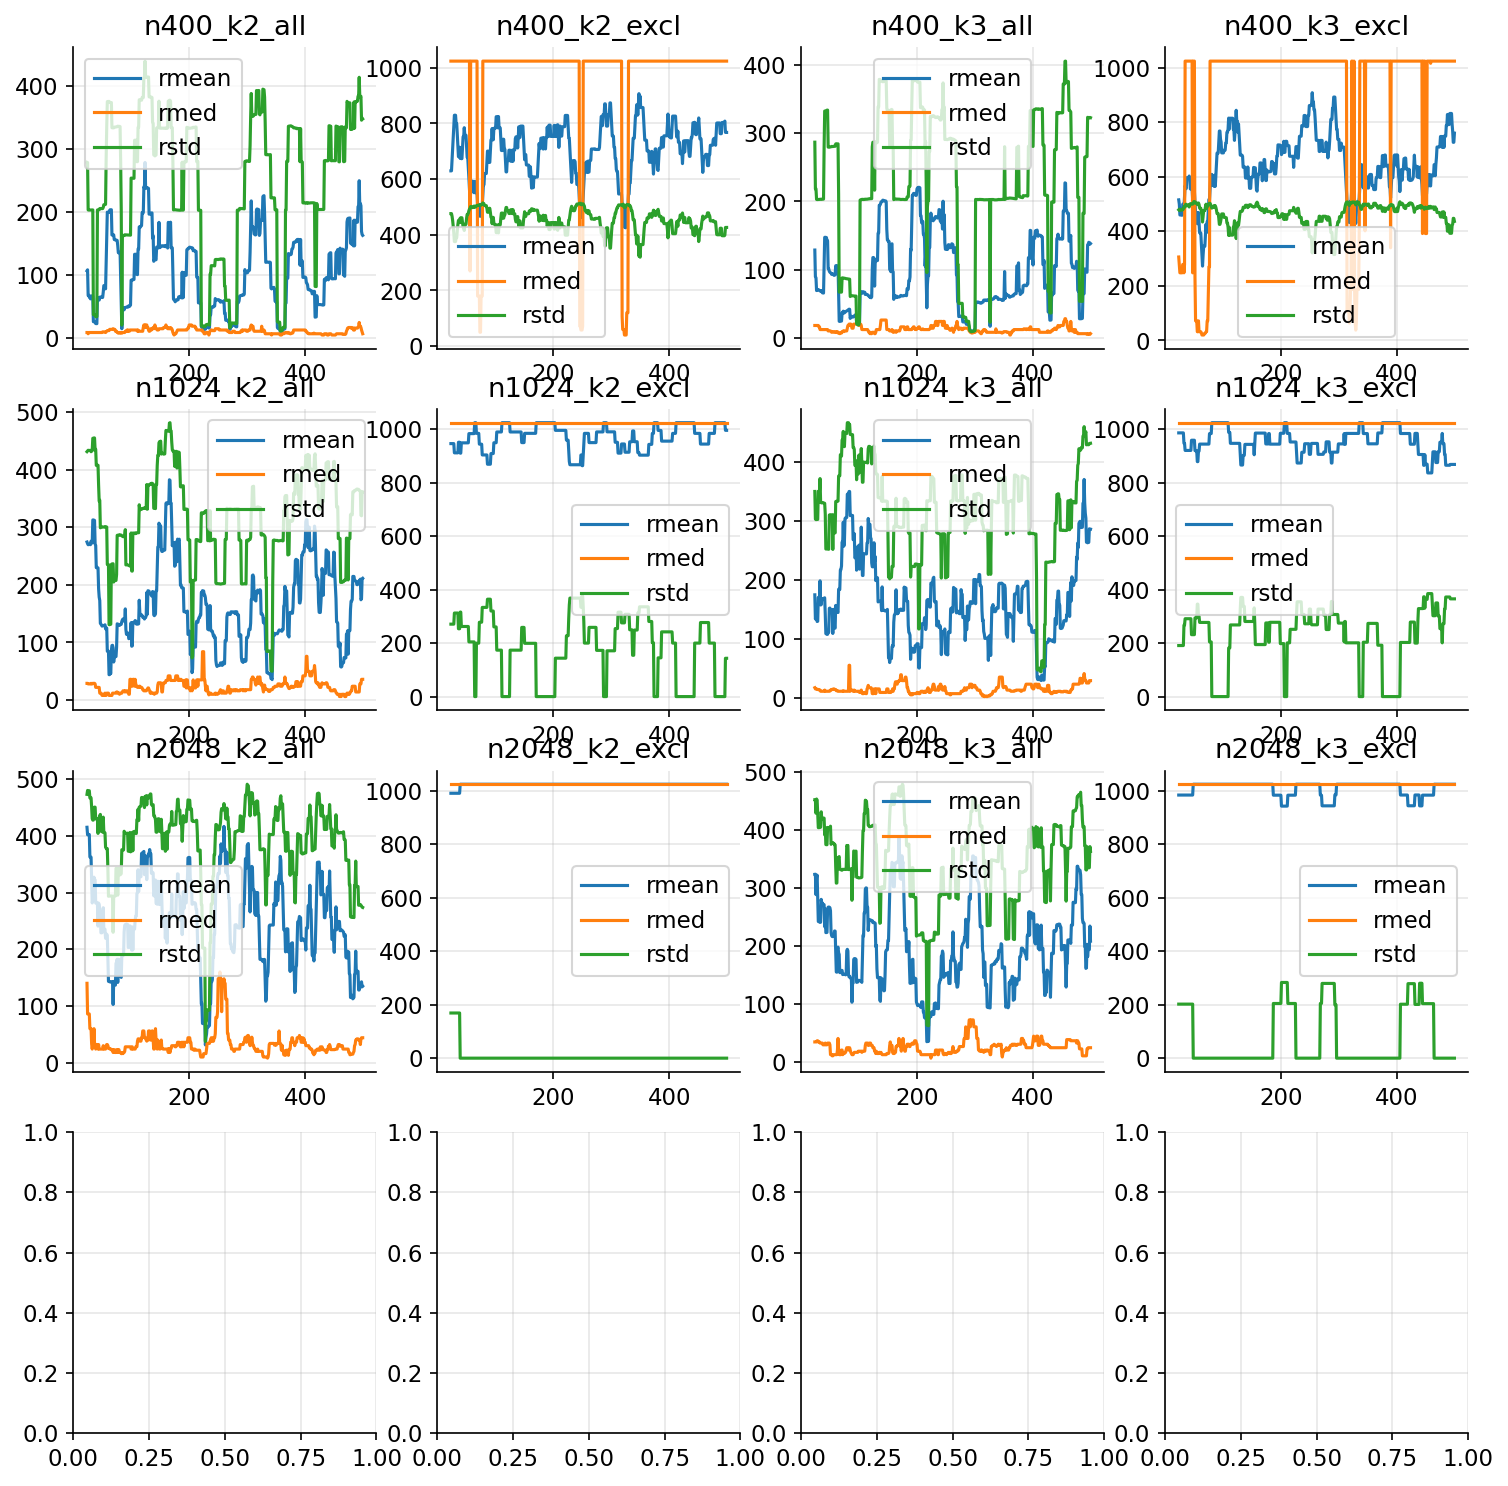

In [172]:
import itertools

cols = [
    # "val",
    "rmean",
    "rmed",
    # "rstd",
]


def rolling_stats(df: pd.DataFrame, column: str, window: int = 25) -> pd.DataFrame:
    col = df[column]
    result = pd.DataFrame(
        {
            "val": col,
            "rmean": col.rolling(window).mean(),
            "rmed": col.rolling(window).median(),
            "rstd": col.rolling(window).std(),
        }
    )
    return result


n_vals = [15, 50, 100, 191, 400, 1024, 2048]
k_vals = [2, 3, 4]
exclude_taut_and_cond_vals = ["", "-e"]

matrix = list(itertools.product(n_vals, k_vals, exclude_taut_and_cond_vals))
n = len(matrix)


for i, (n, k, e) in enumerate(matrix):
    if not i % 16:
        fig, axs = plt.subplots(4, 4, figsize=(12, 12))

    ax = axs[(i % 16) // 4, i % 4]
    df = load(
        f"fig_4_n{n}_k{k}_{'excl' if e else 'all'}.csv", output_dir="stability_output"
    )
    x = rolling_stats(df, "cycle_length")
    ax.set_title(f"n{n}_k{k}_{'excl' if e else 'all'}")
    for col in cols:
        ax.plot(x[col], label=col)
    ax.legend()

    if i % 16 == 15 or i == n - 1:
        plt.tight_layout()
        # plt.savefig(os.path.join(OUTPUT_DIR, filename), bbox_inches="tight")
        plt.show()